#  03. Cost Mode → Routing to Low-Cost Models

**Theme**: When operating in **cheap mode** or under **cost budget constraints**, the Load Balancer routes to **low-cost models**.

## Key Insight
- Different modes prioritize different objectives (accuracy, speed, cost, balanced)
- In **cheap mode**, LB favors low-cost models even if slower
- Cost budgets can force model selection regardless of router preference

---
## 1. Common Setup

In [19]:
import sys
from pathlib import Path
# Path setup
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent.parent
ARTEMIS_DIR = ROOT_DIR / 'artemis_final'
CHECKPOINTS_DIR = ARTEMIS_DIR / 'checkpoints'
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ARTEMIS_DIR))

# Imports
from sqlalchemy import create_engine, text
from artemis_final.load_balancer.public_api import (
    load_capacity_config,
    StatsRegistry,
    ArtemisLoadBalancer,
    RouterOutput,
    SchedulingContext,
    ModelCapacityConfig
)
import time 
import matplotlib.pyplot as plt
import pandas as pd

In [3]:

from artemis_final.ares.configs.db_config import DB_URL, TABLES

DB_AVAILABLE = True

# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None

Device: mps


In [4]:

try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


In [5]:
# Load samples
def load_samples(n=20):
    if not DB_AVAILABLE:
        return [{'sample_id': f'sample_{i}', 'prompt': f'Prompt {i}', 'router_task': 'vqa'} for i in range(n)]
    try:
        engine = create_engine(DB_URL)
        with engine.connect() as conn:
            result = conn.execute(text(f"SELECT sample_id, prompt_text, router_task FROM {TABLES['samples']} WHERE prompt_text IS NOT NULL ORDER BY RANDOM() LIMIT {n}"))
            return [{'sample_id': r[0], 'prompt': r[1], 'router_task': r[2] or 'vqa'} for r in result.fetchall()]
    except Exception as e:
        print(f"️ DB Error: {e}")
        return [{'sample_id': f'sample_{i}', 'prompt': f'Prompt {i}', 'router_task': 'vqa'} for i in range(n)]

samples = load_samples(20)
print(f" Loaded {len(samples)} samples")

 Loaded 20 samples


In [6]:
# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None
try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

Device: mps
[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


---
## 2. Model Setup with Clear Cost Differences

In [13]:
# Load Capacity Config (Updated)
from artemis_final.load_balancer.public_api import load_capacity_config

try:
    # Try to load the config that matches the router's models
    capacity_config = load_capacity_config('multitask_router_v1')
    print(" Loaded capacity config for multitask_router_v1")
except Exception as e:
    print(f"️ Failed to load multitask_router_v1 config: {e}")
    print("   Falling back to default capacity config (gemma, qwen, deepseek)")
    # Fallback to a known good config if the specific one isn't found
    capacity_config = {
        'gemma_3_27b': {'max_capacity': 100, 'cost_per_token': 0.0001},
        'qwen_1_8b': {'max_capacity': 100, 'cost_per_token': 0.00005},
        'deepseek_6_7b': {'max_capacity': 100, 'cost_per_token': 0.00008},
    }
    print("   Using hardcoded fallback capacity config.")

print("Capacity Config:")                         
for model, config in capacity_config.items():
    print(f"  {model}: {config}")

# Placeholder for VLM inference, if applicable
call_vlm = False # Set to True if VLM inference is desired
print(f"\nVLM INFERENCE: Skipped (call_vlm={call_vlm})\n")


 Loaded capacity config for multitask_router_v1
Capacity Config:
  gemma_3_27b: ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, min_replicas=1, max_replicas=2, sla_ms=4000, max_qps_per_replica=0.5, cost_per_request_usd=0.0005, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen3_vl_8b_thinking: ModelCapacityConfig(model_name='qwen3_vl_8b_thinking', base_latency_ms=1200, min_replicas=1, max_replicas=3, sla_ms=3000, max_qps_per_replica=0.8, cost_per_request_usd=0.003, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen2_5_vl_7b: ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, min_replicas=1, max_replicas=4, sla_ms=2500, max_qps_per_replica=1.2, cost_per_request_usd=0.0004, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen2_5_vl

In [14]:
# Load Balancer & Config
try:
    model_configs = load_capacity_config()
except:
    model_configs = {
        'qwen2_5_vl_7b': ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, cost_per_request_usd=0.005),
        'gemma_3_27b': ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, cost_per_request_usd=0.01),
        'deepseek_ocr': ModelCapacityConfig(model_name='deepseek_ocr', base_latency_ms=400, cost_per_request_usd=0.002, sla_ms=1000),
    }


In [15]:
# Stats registry
stats = StatsRegistry()
for task in ['vqa', 'ocr']:
    for m, cfg in model_configs.items():
        stats.update_latency(task, m, cfg.base_latency_ms)
        # Accuracy inversely related to cost for demo
        acc = 0.95 if 'premium' in m else (0.88 if 'medium' in m else 0.80)
        stats.update_accuracy(task, m, acc)
        stats.update_cost(task, m, cfg.cost_per_request_usd)

print(" Stats registry ready")

 Stats registry ready


---
## 3. Compare Modes: Accuracy vs Cheap

In [16]:
def run_experiment(samples, mode, stats, model_configs):
    """Run requests through LB with a specific mode and collect results."""
    lb = ArtemisLoadBalancer(
        model_configs=model_configs,
        stats_registry=stats,
        latency_sla_ms={'default': 3000},
        scheduling_mode='capacity_aware',
        simulation_only=True,
    )
    
    results = []
    for sample in samples:
        # Get router prediction for this mode
        if router:
            try:
                rr = router.route(prompt=sample['prompt'], mode=mode, metadata={'router_task': sample['router_task']})
                probs = get_router_probs(rr)
                preferred = rr['chosen_model']
            except:
                models = list(model_configs.keys())
                probs = {m: 1.0/len(models) for m in models}
                preferred = models[0]
        else:
            models = list(model_configs.keys())
            # Simulate mode-aware routing
            if mode == 'cheap':
                probs = {'cheap_model': 0.7, 'medium_model': 0.2, 'premium_model': 0.1}
            elif mode == 'accuracy':
                probs = {'cheap_model': 0.1, 'medium_model': 0.2, 'premium_model': 0.7}
            else:
                probs = {m: 1.0/len(models) for m in models}
            preferred = max(probs, key=probs.get)
        
        ro = RouterOutput(
            sample_id=sample['sample_id'], task_type=sample['router_task'],
            router_probs=probs, preferred_model=preferred, max_prob=probs.get(preferred, 0.5)
        )
        ctx = SchedulingContext(arrival_ts_ms=time.time()*1000, load_profile=mode)
        dec = lb.schedule(ro, ctx)
        # === VLM Inference (Injected) ===
        if 'call_vlm' in locals() and call_vlm and vlm_client:
            # Try to get image data
            img_data = sample.get('image_bytes') or sample.get('image')
            if img_data:
                try:
                    # If bytes, convert to PIL or pass as is (Client handles it)
                    from io import BytesIO
                    from PIL import Image
                    if isinstance(img_data, bytes):
                        img_input = Image.open(BytesIO(img_data))
                    else:
                        img_input = img_data
                        
                    print(f"   Invoking VLM ({dec.chosen_model})...")
                    vlm_result = vlm_client.vlm.run_image(
                        image=img_input,
                        text=sample['prompt'],
                        models=[dec.chosen_model],
                        max_tokens=200
                    )
                    
                    # Extract result
                    model_resp = vlm_result.get(dec.chosen_model, {})
                    if model_resp.get('ok'):
                        print(f"   VLM Response: {model_resp.get('response_text')[:100]}...")
                    else:
                        print(f"   VLM Error: {model_resp.get('error')}")
                        
                except Exception as e:
                    print(f"   VLM call failed: {e}")
            else:
               pass # No image data for VLM


        
        results.append({
            'mode': mode,
            'sample_id': sample['sample_id'],
            'router_choice': preferred,
            'lb_choice': dec.chosen_model,
            'cost_usd': dec.est_cost_usd,
            'latency_ms': dec.total_latency_ms,
            'accuracy': dec.est_accuracy,
        })
    
    return pd.DataFrame(results)

In [ ]:

# === VLM Client Setup ===
from artemis_final.utils.vlm_client_factory import get_vlm_client

# Initialize Client
# simulation_only=False means we try to load real models from config.
# If config is missing or fails, it falls back to Mock.
# Note: In the notebooks below, specific simulation_only flags might override this intention for the Load Balancer,
# but we prepare the client here.
try:
    # Check if 'lb' exists and use its setting, otherwise default to False (Real)
    sim_mode = lb.simulation_only if 'lb' in locals() else False
    vlm_client = get_vlm_client(simulation_only=sim_mode)
    print(f" VLM Client initialized: {type(vlm_client).__name__}")
except Exception as e:
    print(f" Could not initialize VLM client: {e}")
    vlm_client = None


In [17]:
# Run experiments for different modes
modes = ['accuracy', 'balanced', 'cheap', 'fast']
all_results = []

for mode in modes:
    print(f"\n Running mode: {mode}")
    df_mode = run_experiment(samples, mode, stats, model_configs)
    all_results.append(df_mode)
    
    print(f"   Avg Cost: ${df_mode['cost_usd'].mean():.4f}")
    print(f"   Total Cost: ${df_mode['cost_usd'].sum():.4f}")
    print(f"   Model Usage: {df_mode['lb_choice'].value_counts().to_dict()}")

df_all = pd.concat(all_results, ignore_index=True)

Missing 'avg_accuracy' stats for task='document_ocr', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='document_ocr', model='qwen2_5_vl_3b'. Using default value.
Missing 'cost_per_request_usd' stats for task='document_ocr', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='document_ocr', model='gemma_3_27b'. Using default value.
Missing 'cost_per_request_usd' stats for task='document_ocr', model='gemma_3_27b'. Using default value.
Missing 'avg_accuracy' stats for task='document_ocr', model='gemma_3_27b'. Using default value.
Missing 'avg_latency_ms' stats for task='document_ocr', model='qwen2_5_vl_7b'. Using default value.
Missing 'cost_per_request_usd' stats for task='document_ocr', model='qwen2_5_vl_7b'. Using default value.
Missing 'avg_accuracy' stats for task='document_ocr', model='qwen2_5_vl_7b'. Using default value.


Missing 'avg_accuracy' stats for task='handwriting_ocr', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='handwriting_ocr', model='qwen2_5_vl_3b'. Using default value.
Missing 'cost_per_request_usd' stats for task='handwriting_ocr', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='handwriting_ocr', model='gemma_3_27b'. Using default value.
Missing 'cost_per_request_usd' stats for task='handwriting_ocr', model='gemma_3_27b'. Using default value.
Missing 'avg_accuracy' stats for task='handwriting_ocr', model='gemma_3_27b'. Using default value.
Missing 'avg_latency_ms' stats for task='handwriting_ocr', model='deepseek_ocr'. Using default value.
Missing 'cost_per_request_usd' stats for task='handwriting_ocr', model='deepseek_ocr'. Using default value.
Missing 'avg_accuracy' stats for task='handwriting_ocr', model='deepseek_ocr'. Using default value.
Missing 'avg_accuracy' stats for task='abstract_reasoning', model='qwe


 Running mode: accuracy


Missing 'avg_accuracy' stats for task='ui_captioning', model='qwen3_vl_8b_thinking'. Using default value.
Missing 'avg_latency_ms' stats for task='ui_captioning', model='qwen3_vl_8b_thinking'. Using default value.
Missing 'cost_per_request_usd' stats for task='ui_captioning', model='qwen3_vl_8b_thinking'. Using default value.
Missing 'avg_latency_ms' stats for task='ui_captioning', model='deepseek_ocr'. Using default value.
Missing 'cost_per_request_usd' stats for task='ui_captioning', model='deepseek_ocr'. Using default value.
Missing 'avg_accuracy' stats for task='ui_captioning', model='deepseek_ocr'. Using default value.
Missing 'avg_latency_ms' stats for task='ui_captioning', model='gemma_3_27b'. Using default value.
Missing 'cost_per_request_usd' stats for task='ui_captioning', model='gemma_3_27b'. Using default value.
Missing 'avg_accuracy' stats for task='ui_captioning', model='gemma_3_27b'. Using default value.
Missing 'avg_accuracy' stats for task='chart_reasoning', model='gem

   Avg Cost: $0.0000
   Total Cost: $0.0000
   Model Usage: {'qwen2_5_vl_3b': 10, 'qwen2_5_vl_7b': 4, 'deepseek_ocr': 2, 'qwen3_vl_8b_thinking': 2, 'gemma_3_27b': 2}

 Running mode: balanced


Missing 'avg_latency_ms' stats for task='ui_captioning', model='qwen2_5_vl_3b'. Using default value.
Missing 'cost_per_request_usd' stats for task='ui_captioning', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_accuracy' stats for task='ui_captioning', model='qwen2_5_vl_3b'. Using default value.
Missing 'avg_latency_ms' stats for task='icon_reasoning', model='qwen2_5_vl_7b'. Using default value.
Missing 'cost_per_request_usd' stats for task='icon_reasoning', model='qwen2_5_vl_7b'. Using default value.
Missing 'avg_accuracy' stats for task='icon_reasoning', model='qwen2_5_vl_7b'. Using default value.
Missing 'avg_latency_ms' stats for task='medical_report', model='qwen2_5_vl_7b'. Using default value.
Missing 'cost_per_request_usd' stats for task='medical_report', model='qwen2_5_vl_7b'. Using default value.
Missing 'avg_accuracy' stats for task='medical_report', model='qwen2_5_vl_7b'. Using default value.
Missing 'avg_latency_ms' stats for task='medical_report', model='gemma_3_

   Avg Cost: $0.0000
   Total Cost: $0.0000
   Model Usage: {'qwen2_5_vl_3b': 14, 'qwen2_5_vl_7b': 4, 'deepseek_ocr': 1, 'gemma_3_27b': 1}

 Running mode: cheap


Missing 'avg_accuracy' stats for task='chart_reasoning', model='deepseek_ocr'. Using default value.
Missing 'avg_latency_ms' stats for task='chart_reasoning', model='deepseek_ocr'. Using default value.
Missing 'cost_per_request_usd' stats for task='chart_reasoning', model='deepseek_ocr'. Using default value.
Missing 'avg_accuracy' stats for task='geometry_reasoning', model='deepseek_ocr'. Using default value.
Missing 'avg_latency_ms' stats for task='geometry_reasoning', model='deepseek_ocr'. Using default value.
Missing 'cost_per_request_usd' stats for task='geometry_reasoning', model='deepseek_ocr'. Using default value.
Missing 'avg_accuracy' stats for task='image_captioning', model='gemma_3_27b'. Using default value.
Missing 'avg_latency_ms' stats for task='image_captioning', model='gemma_3_27b'. Using default value.
Missing 'cost_per_request_usd' stats for task='image_captioning', model='gemma_3_27b'. Using default value.
Missing 'avg_latency_ms' stats for task='document_ocr', model

   Avg Cost: $0.0000
   Total Cost: $0.0000
   Model Usage: {'deepseek_ocr': 11, 'qwen2_5_vl_3b': 7, 'gemma_3_27b': 2}

 Running mode: fast
   Avg Cost: $0.0000
   Total Cost: $0.0000
   Model Usage: {'deepseek_ocr': 8, 'gemma_3_27b': 7, 'qwen2_5_vl_3b': 5}


In [18]:
# Summary by mode
summary = df_all.groupby('mode').agg({
    'cost_usd': ['mean', 'sum'],
    'latency_ms': 'mean',
    'accuracy': 'mean',
}).round(4)
summary.columns = ['avg_cost', 'total_cost', 'avg_latency', 'avg_accuracy']

print("\n Mode Comparison:")
display(summary)


 Mode Comparison:


,avg_cost,total_cost,avg_latency,avg_accuracy
mode,,,,
accuracy,0.0,0.0,1000.0,0.0
balanced,0.0,0.0,1000.0,0.0
cheap,0.0,0.0,1000.0,0.0
fast,0.0,0.0,1000.0,0.0


---
## 4. Visualization: Cost vs Accuracy Trade-off

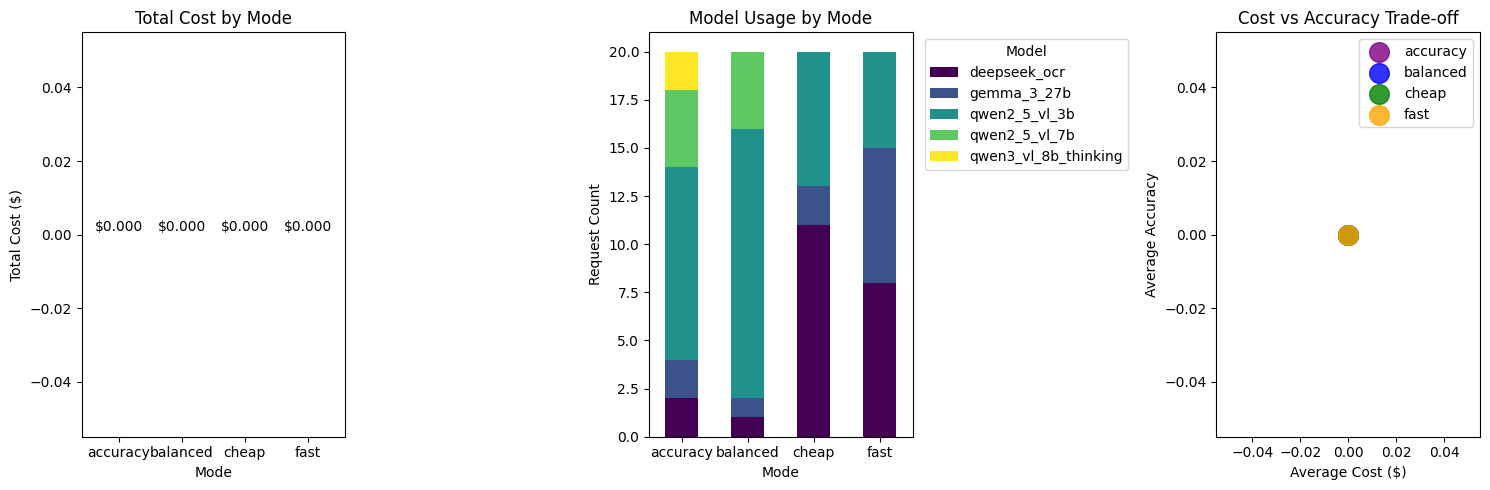


 Insight: 'cheap' mode routes to low-cost models, trading accuracy for cost.
   'accuracy' mode routes to premium models, incurring higher costs.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Cost by Mode
ax1 = axes[0]
mode_costs = df_all.groupby('mode')['cost_usd'].sum()
colors = {'cheap': 'green', 'balanced': 'blue', 'accuracy': 'purple', 'fast': 'orange'}
bars = ax1.bar(mode_costs.index, mode_costs.values, color=[colors.get(m, 'gray') for m in mode_costs.index])
ax1.set_xlabel('Mode')
ax1.set_ylabel('Total Cost ($)')
ax1.set_title('Total Cost by Mode')
for bar, val in zip(bars, mode_costs.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'${val:.3f}', ha='center', fontsize=10)

# Plot 2: Model Usage by Mode
ax2 = axes[1]
model_usage = df_all.groupby(['mode', 'lb_choice']).size().unstack(fill_value=0)
model_usage.plot(kind='bar', stacked=True, ax=ax2, colormap='viridis')
ax2.set_xlabel('Mode')
ax2.set_ylabel('Request Count')
ax2.set_title('Model Usage by Mode')
ax2.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=0)

# Plot 3: Cost vs Accuracy Trade-off
ax3 = axes[2]
for mode in modes:
    df_mode = df_all[df_all['mode'] == mode]
    ax3.scatter(df_mode['cost_usd'].mean(), df_mode['accuracy'].mean(), 
                s=200, label=mode, c=colors.get(mode, 'gray'), alpha=0.8)
ax3.set_xlabel('Average Cost ($)')
ax3.set_ylabel('Average Accuracy')
ax3.set_title('Cost vs Accuracy Trade-off')
ax3.legend()

plt.tight_layout()
plt.show()

print("\n Insight: 'cheap' mode routes to low-cost models, trading accuracy for cost.")
print("   'accuracy' mode routes to premium models, incurring higher costs.")

---
## Summary

This notebook demonstrated:
- **cheap mode** routes to low-cost models, minimizing expenses
- **accuracy mode** routes to premium models for best quality
- LB respects mode preferences when making routing decisions
- Clear trade-off between cost and accuracy